# Does a smooth illumination gradient explain disk's weak averaging gain?

Follow-up on `test_bead_round_averaging.ipynb`
(`prompt_history/2026_09_02_1805_corner_vs_diagonal_residuals_and_bead_
averaging.md`): averaging aligned beads frames across rounds cut background
noise std to only 1.12x for `epi` (vs. the 3.16x `sqrt(10)` independent-noise
rounds would predict) and to 0.95x for `disk` -- **no improvement at all**
(vs. `sqrt(2)`=1.41x), with disk's own zoomed comparison figure showing a
visible fixed-pattern vertical striping/gradient in the background that
doesn't average out because it's identical in every round.

Question: is that background pattern actually a smooth, spatially-slow
illumination gradient (the kind a flat-field or local-background correction
removes), or something else (e.g. real per-round instrument noise)? And if
it *is* a smooth gradient, does subtracting it before averaging recover more
of the independent-noise-averaging benefit?

**Characterized first, not assumed** (Section 4): FFT of the row-mean and
column-mean profiles of each dataset's own round-1 beads frame.
`disk`'s frame has a low mean/std (103 / 6.9 -- close to the camera's dark
level, i.e. genuinely low bead signal) and its column-mean profile is
dominated by very low spatial frequencies (period 576-768 px across a
2304 px frame -- a slow few-cycle gradient, not fine per-line banding),
with the modulation a large fraction (~28%) of the frame's own mean.
`epi`'s frame has a far higher mean/std (5637 / 8065) where the dominant
row/column-mean structure is real bead signal, not a background gradient.
This is why the hypothesis below expects a correction to matter for `disk`
but not `epi` -- confirmed or refuted with real numbers in Section 7, not
assumed from the characterization alone.

Reuses `test_bead_round_averaging.ipynb`'s own dataset-resolution,
FiducialCorrelationWarp-offset mapping, and round1-vs-average pipeline
(kept self-contained here, same convention as that notebook relative to
`test_stitching.ipynb`) with one addition: a local-background-subtraction
step, applied to each round's raw beads frame before alignment (the
illumination gradient is a fixed property of the camera/optics in
camera-pixel coordinates, not the sample, so it belongs before the
few-pixel per-round alignment shift, not after).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift, gaussian_filter

MERCI_DIR = Path(os.getcwd()).parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift

NOTEBOOK_NAME = "test_bead_background_correction"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same two real BC555_sample_05 datasets as test_bead_round_averaging.ipynb.
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]

IMAGE_SUFFIX = ".zarr"
BEAD_FRAME_INDEX = 0
ROUND_TYPES_TO_USE = ("cells", "bits")

# Local-background estimate = a heavily Gaussian-smoothed copy of the frame
# itself (no other FOVs needed, unlike MERci.analysis.ffc's multi-FOV flat
# field). sigma_px=50 matches MERci.analysis.ffc.compute_ffc_field_for_color's
# own default smooth_sigma_px -- same repo convention for "large enough to
# average out bead spots (a few px), small enough to still track a
# few-hundred-px-scale gradient".
BG_SIGMA_PX = 50.0

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets to analyze: {[label for label, _ in DATASETS]}  |  BG_SIGMA_PX={BG_SIGMA_PX}")

Datasets to analyze: ['epi', 'disk']  |  BG_SIGMA_PX=50.0


## 3 — Resolve dataset geometry + pick one representative FOV

Identical to `test_bead_round_averaging.ipynb` Section 3.

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    full_positions = load_positions(config.positions_txt)
    pixel_size_um  = get_camera_pixel_size_um(microscope)

    round_ids = []
    for rid in meta.valid_round_ids():
        series = meta.series_for_round(rid)
        if series and (series[0].imaging_type or "").strip().lower() in ROUND_TYPES_TO_USE:
            round_ids.append(rid)
    round_ids.sort()
    cells_round_id = next(rid for rid in round_ids
                           if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
    bits_round_ids = [rid for rid in round_ids if rid != cells_round_id]

    cells_fov_ids = sorted(meta.fovs)
    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    centroid   = coords_arr.mean(axis=0)
    dist       = np.hypot(coords_arr[:, 0] - centroid[0], coords_arr[:, 1] - centroid[1])
    for fov_id in [cells_fov_ids[i] for i in np.argsort(dist)]:
        if all(meta.series_for_round(rid)[0].resolve_path(fov_id, config.image_suffix).exists()
               for rid in round_ids):
            representative_fov = fov_id
            break
    else:
        raise RuntimeError(f"[{dataset_label}] No FOV has on-disk data for every round in {round_ids}")

    figures_dir = config.analysis_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] SAMPLE_DIR        : {sample_dir}")
    print(f"[{dataset_label}] MICROSCOPE        : {microscope}")
    print(f"[{dataset_label}] Rounds used       : {round_ids}  (cells={cells_round_id}, bits={bits_round_ids})")
    print(f"[{dataset_label}] Representative FOV: {representative_fov}  (closest-to-centroid with full data)")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "sample_name": sample_name,
        "microscope": microscope, "config": config, "meta": meta,
        "pixel_size_um": pixel_size_um, "cells_round_id": cells_round_id, "bits_round_ids": bits_round_ids,
        "round_ids": round_ids, "representative_fov": representative_fov, "figures_dir": figures_dir,
    }

## 4 — Characterize the background: is it a smooth gradient?

Row-mean and column-mean profiles of round 1's own beads frame, plus an FFT
of each profile to find the dominant spatial period. A slow, few-cycle
period (large fraction of the frame width) is consistent with an
illumination/vignette gradient; a period of a few px would instead point to
per-line sensor/readout banding, which a large-sigma blur would NOT
correctly model as background.

In [4]:
def characterize_background(dataset_geo):
    label, meta, config = dataset_geo["dataset_label"], dataset_geo["meta"], dataset_geo["config"]
    fov_id, cells_round_id = dataset_geo["representative_fov"], dataset_geo["cells_round_id"]
    series = meta.series_for_round(cells_round_id)[0]
    path = series.resolve_path(fov_id, config.image_suffix)
    frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                               frame_width=config.frame_width, frame_height=config.frame_height)[0].astype(float)

    row_mean, col_mean = frame.mean(axis=1), frame.mean(axis=0)

    def top_period(profile):
        detrended = profile - profile.mean()
        fft = np.abs(np.fft.rfft(detrended))
        freqs = np.fft.rfftfreq(len(detrended))
        i = np.argmax(fft[1:]) + 1   # skip DC
        return (1 / freqs[i]) if freqs[i] > 0 else np.inf

    print(f"[{label}] frame mean={frame.mean():.1f}  std={frame.std():.1f}")
    print(f"[{label}] row_mean range=({row_mean.min():.1f},{row_mean.max():.1f})"
          f"  dominant period={top_period(row_mean):.0f} px  (frame height={frame.shape[0]})")
    print(f"[{label}] col_mean range=({col_mean.min():.1f},{col_mean.max():.1f})"
          f"  dominant period={top_period(col_mean):.0f} px  (frame width={frame.shape[1]})")
    return frame, row_mean, col_mean


for _, dataset_dir in DATASETS:
    pass  # geometry resolved fresh per dataset below, this cell just defines the function

[epi] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
[epi] MICROSCOPE        : MF3
[epi] Rounds used       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (cells=1, bits=[2, 3, 4, 5, 6, 7, 8, 9, 10])
[epi] Representative FOV: 221  (closest-to-centroid with full data)


[epi] frame mean=5636.6  std=8064.5
[epi] row_mean range=(3306.7,8062.9)  dominant period=2048 px  (frame height=2048)
[epi] col_mean range=(1728.3,9763.9)  dominant period=2048 px  (frame width=2048)
[disk] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
[disk] MICROSCOPE        : ST2
[disk] Rounds used       : [1, 2]  (cells=1, bits=[2])
[disk] Representative FOV: 301  (closest-to-centroid with full data)


[disk] frame mean=103.4  std=6.9
[disk] row_mean range=(100.4,109.1)  dominant period=2304 px  (frame height=2304)
[disk] col_mean range=(93.9,123.1)  dominant period=1152 px  (frame width=2304)


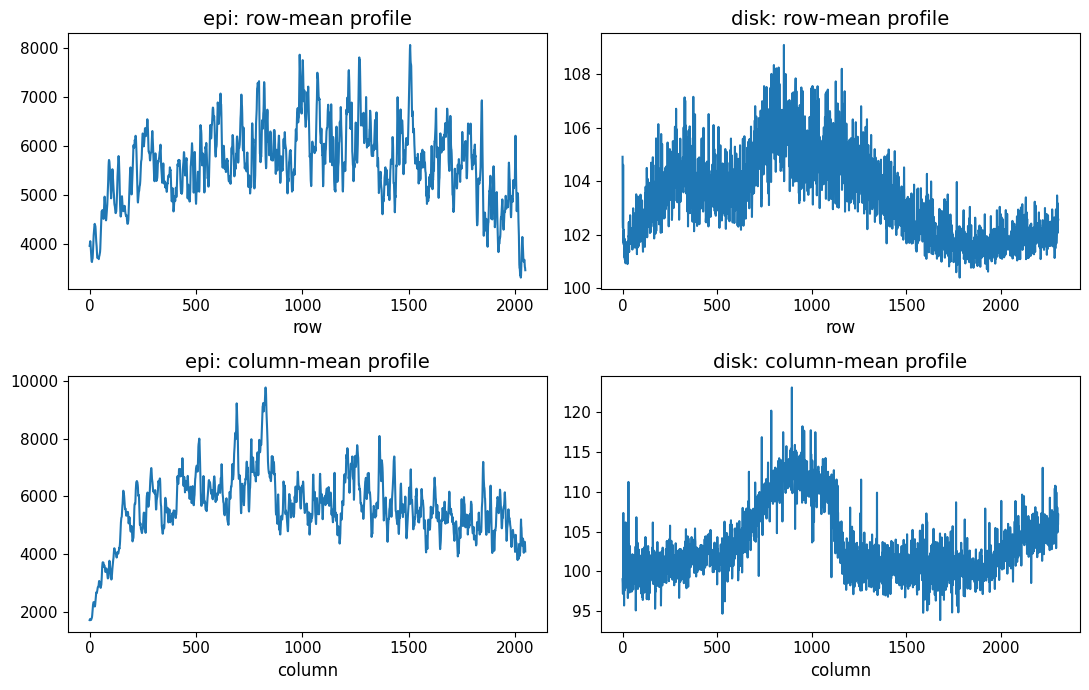

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.background_profiles.png


In [5]:
BG_CHARACTERIZATION = {}
for dataset_label, dataset_dir in DATASETS:
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    frame, row_mean, col_mean = characterize_background(dataset_geo)
    BG_CHARACTERIZATION[dataset_label] = {
        "dataset_geo": dataset_geo, "frame": frame, "row_mean": row_mean, "col_mean": col_mean,
    }

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, (dataset_label, C) in enumerate(BG_CHARACTERIZATION.items()):
    axes[0, col].plot(C["row_mean"])
    axes[0, col].set_title(f"{dataset_label}: row-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[0, col].set_xlabel("row", fontsize=PLOT_LABEL_FONTSIZE)
    axes[1, col].plot(C["col_mean"])
    axes[1, col].set_title(f"{dataset_label}: column-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[1, col].set_xlabel("column", fontsize=PLOT_LABEL_FONTSIZE)
    for ax in (axes[0, col], axes[1, col]):
        ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.background_profiles.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 5 — Map each round to its MERlin offset row, load + align + correct

Same offset-row mapping and empirically-verified `relative_shift_to_cells`
formula as `test_bead_round_averaging.ipynb` Sections 4-5 (see that
notebook's own docstring for the verification this formula is based on --
not re-derived here).

Local background subtraction (`subtract_local_background`) is applied to
each round's RAW beads frame, before alignment: the background field is a
property of the camera/illumination in camera-pixel coordinates, and the
per-round alignment shift is at most a few px (verified in
`test_bead_round_averaging.ipynb`), so applying the correction before or
after the shift makes negligible difference here -- before is simpler and
matches the field's actual physical origin.

Both the RAW and BACKGROUND-CORRECTED pipelines are run in parallel so
Section 7 can compare round1-vs-average under each.

In [6]:
def resolve_round_offset_rows(dataset_geo):
    sample_dir = dataset_geo["sample_dir"]
    dataorg_csvs = sorted((sample_dir / "merlin" / "dataorganization").glob("*.csv"))
    if len(dataorg_csvs) != 1:
        raise RuntimeError(f"Expected exactly 1 data-organization CSV, found {dataorg_csvs}")
    dataorg = pd.read_csv(dataorg_csvs[0])

    dapi_rows = dataorg.index[dataorg["channelName"] == "DAPI"].tolist()
    if len(dapi_rows) != 1:
        raise RuntimeError(f"Expected exactly 1 DAPI row in {dataorg_csvs[0]}, found {len(dapi_rows)}")
    cells_row = int(dapi_rows[0])

    bits_dataorg = dataorg[dataorg["channelName"] != "DAPI"]
    bits_rows_by_round = (bits_dataorg.groupby("imagingRound").apply(lambda g: int(g.index[0]))
                                        .sort_index().tolist())

    bits_round_ids = sorted(dataset_geo["bits_round_ids"])
    if len(bits_rows_by_round) != len(bits_round_ids):
        raise RuntimeError(
            f"[{dataset_geo['dataset_label']}] {len(bits_rows_by_round)} distinct bits imagingRound groups "
            f"in {dataorg_csvs[0]} != {len(bits_round_ids)} bits rounds in round_info.csv."
        )

    round_offset_row = {dataset_geo["cells_round_id"]: cells_row}
    round_offset_row.update(dict(zip(bits_round_ids, bits_rows_by_round)))
    return round_offset_row


def subtract_local_background(frame, sigma_px=BG_SIGMA_PX):
    """Subtract a heavily Gaussian-smoothed copy of *frame* from itself,
    adding the smoothed field's own mean back so the corrected frame stays
    on the same intensity scale (flattens the spatial gradient, doesn't
    change the overall brightness level)."""
    bg = gaussian_filter(frame.astype(float), sigma=sigma_px)
    return frame.astype(float) - bg + bg.mean()


def load_align_pipelines(dataset_geo, round_offset_row):
    label   = dataset_geo["dataset_label"]
    meta    = dataset_geo["meta"]
    config  = dataset_geo["config"]
    fov_id  = dataset_geo["representative_fov"]
    cells_round_id = dataset_geo["cells_round_id"]

    offsets_path = (dataset_geo["sample_dir"] / "merlin" / "output" / "FiducialCorrelationWarp"
                     / "transformations" / f"offsets_{fov_id}.npy")
    offsets = np.load(offsets_path, allow_pickle=True)

    def load_beads(round_id):
        series = meta.series_for_round(round_id)[0]
        path   = series.resolve_path(fov_id, config.image_suffix)
        return read_image_frames(path, [BEAD_FRAME_INDEX],
                                  frame_width=config.frame_width, frame_height=config.frame_height)[0]

    def tx_ty(round_id):
        row = offsets[round_offset_row[round_id]]
        return row[0, 2], row[1, 2]

    def relative_shift_to_cells(round_id):
        # See test_bead_round_averaging.ipynb Section 5 for the verification
        # this empirically-calibrated formula is based on.
        tx_cells, ty_cells = tx_ty(cells_round_id)
        tx_r, ty_r = tx_ty(round_id)
        return tx_cells - tx_r, ty_r - ty_cells   # (dy_rel, dx_rel) px

    raw_frames = {rid: load_beads(rid) for rid in dataset_geo["round_ids"]}
    corrected_frames = {rid: subtract_local_background(f) for rid, f in raw_frames.items()}

    def align_all(frames_by_round):
        cells_frame = frames_by_round[cells_round_id].astype(float)
        aligned = {cells_round_id: cells_frame}
        for rid in dataset_geo["bits_round_ids"]:
            dy_rel, dx_rel = relative_shift_to_cells(rid)
            aligned[rid] = ndi_shift(frames_by_round[rid].astype(float), shift=(dy_rel, dx_rel),
                                      order=1, mode="nearest")
        return aligned

    aligned_raw = align_all(raw_frames)
    aligned_corrected = align_all(corrected_frames)

    # Verify alignment on the RAW pipeline only (background subtraction
    # doesn't change the measured shift, only the pixel values).
    cells_beads_raw = raw_frames[cells_round_id]
    verify_rows = []
    for rid in dataset_geo["bits_round_ids"]:
        raw_shift, _     = phase_drift(remove_hot_pixels(cells_beads_raw), remove_hot_pixels(raw_frames[rid]), 10)
        aligned_shift, _ = phase_drift(remove_hot_pixels(cells_beads_raw),
                                        remove_hot_pixels(aligned_raw[rid].astype(np.uint16)), 10)
        verify_rows.append({
            "round": rid,
            "residual_before_px": float(np.hypot(*raw_shift)), "residual_after_px": float(np.hypot(*aligned_shift)),
        })
    verify_df = pd.DataFrame(verify_rows)
    ok = (verify_df["residual_after_px"] <= verify_df["residual_before_px"] + 0.5)
    if len(verify_df) and not ok.all():
        raise RuntimeError(f"[{label}] Alignment verification failed -- do not trust the averages.")

    average_raw       = np.mean(np.stack(list(aligned_raw.values()), axis=0), axis=0)
    average_corrected = np.mean(np.stack(list(aligned_corrected.values()), axis=0), axis=0)

    return {
        "round1_raw": aligned_raw[cells_round_id], "average_raw": average_raw,
        "round1_corrected": aligned_corrected[cells_round_id], "average_corrected": average_corrected,
        "verify_df": verify_df,
    }

## 6 — Run both pipelines per dataset (cached)

In [7]:
RESULTS = {}

for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = BG_CHARACTERIZATION[dataset_label]["dataset_geo"]
    round_offset_row = resolve_round_offset_rows(dataset_geo)

    CACHE_DIR = dataset_geo["config"].analysis_dir / "cache" / NOTEBOOK_NAME
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    npz_path = CACHE_DIR / "pipelines.npz"
    csv_path = CACHE_DIR / "verify.csv"

    if not FORCE_RECOMPUTE and npz_path.exists() and csv_path.exists():
        npz = np.load(npz_path)
        pipe = {k: npz[k] for k in ("round1_raw", "average_raw", "round1_corrected", "average_corrected")}
        verify_df = pd.read_csv(csv_path)
        print(f"[{dataset_label}] Loaded cached results from {CACHE_DIR}")
    else:
        pipe = load_align_pipelines(dataset_geo, round_offset_row)
        verify_df = pipe.pop("verify_df")
        np.savez_compressed(npz_path, **pipe)
        verify_df.to_csv(csv_path, index=False)
        print(f"[{dataset_label}] Saved: {npz_path}, {csv_path}")

    n_rounds = len(dataset_geo["round_ids"])
    RESULTS[dataset_label] = {"dataset_geo": dataset_geo, "n_rounds_averaged": n_rounds,
                               "verify_df": verify_df, **pipe}

print(f"\nDatasets analyzed: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===


[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/pipelines.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/verify.csv

=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===


[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/pipelines.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/verify.csv

Datasets analyzed: ['epi', 'disk']


## 7 — Round 1 vs. average, raw vs. background-corrected

Each row uses one contrast stretch (1st-99th percentile of that dataset's
own round-1-raw frame) across all four panels, so differences reflect the
images, not independently-rescaled contrast.

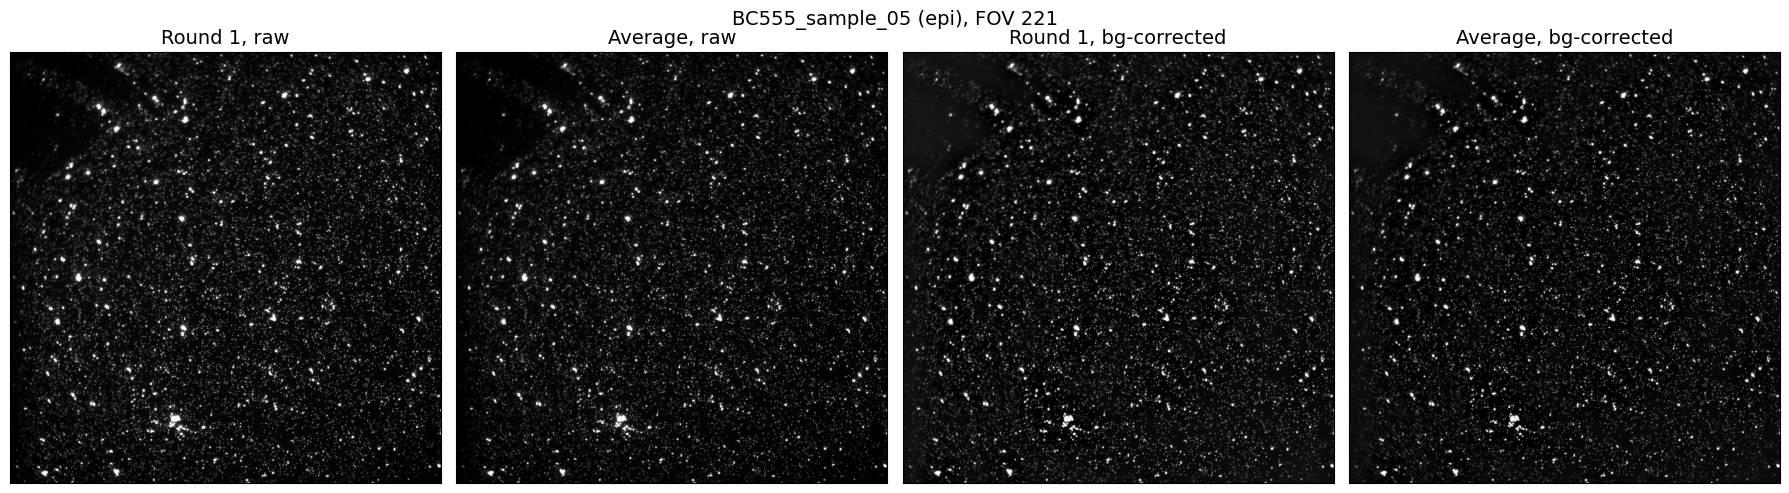

[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


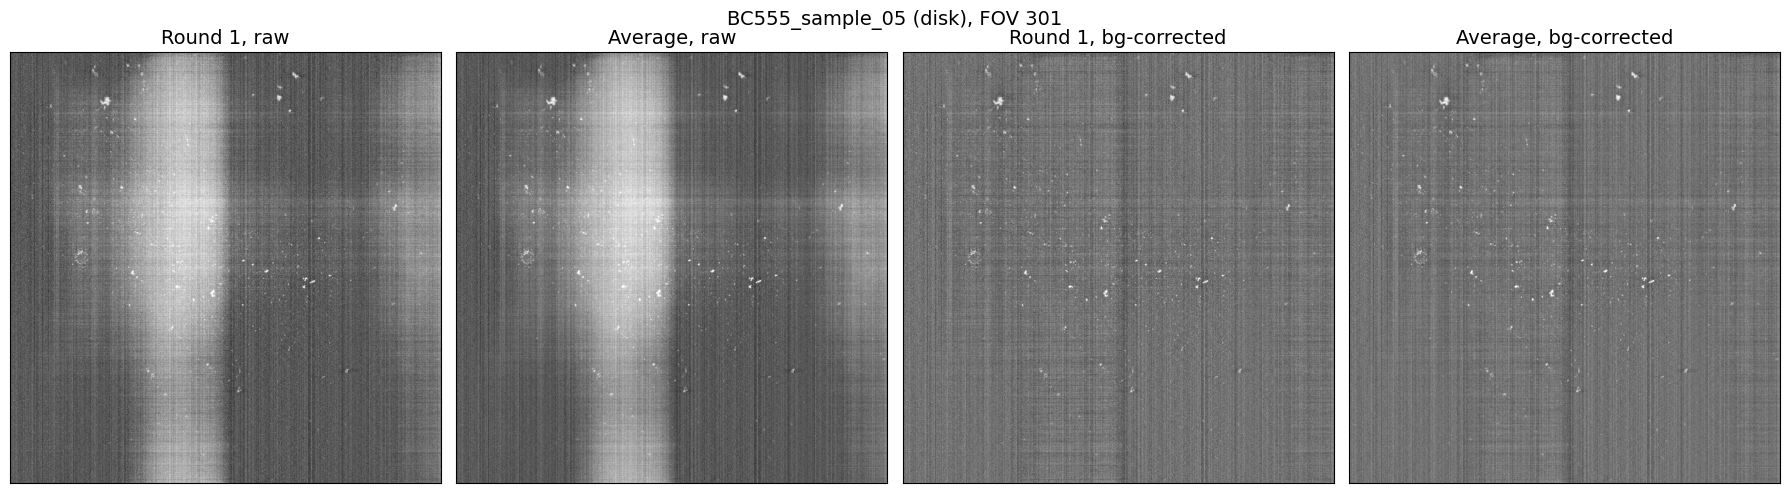

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


In [8]:
for dataset_label, R in RESULTS.items():
    vmin, vmax = np.percentile(R["round1_raw"], [1, 99])
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    panels = [("round1_raw", "Round 1, raw"), ("average_raw", "Average, raw"),
              ("round1_corrected", "Round 1, bg-corrected"), ("average_corrected", "Average, bg-corrected")]
    for ax, (key, title) in zip(axes, panels):
        ax.imshow(R[key], cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{R['dataset_geo']['sample_name']} ({dataset_label}), "
                 f"FOV {R['dataset_geo']['representative_fov']}", fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = R["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.raw_vs_corrected.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[{dataset_label}] Saved: {fig_path}")

## 8 — Does background correction recover more of the averaging benefit?

Same background-noise-std metric as `test_bead_round_averaging.ipynb`
Section 8 (background = round1-raw's own below-median pixels, same pixel
locations used for every image so the comparison is apples to apples),
computed for both the raw and background-corrected pipelines. If the
gradient was responsible for disk's flat 0.95x result, correction should
move `observed_ratio` closer to `expected_ratio_if_independent_noise` for
`disk` and leave `epi` about where it already was.

dataset     pipeline  n_rounds_averaged  background_std_round1  background_std_average  observed_ratio  expected_ratio_if_independent_noise
    epi          raw                 10                512.246                 456.380           1.122                                3.162
    epi bg_corrected                 10                947.842                 845.201           1.121                                3.162
   disk          raw                  2                  3.425                   3.591           0.954                                1.414
   disk bg_corrected                  2                  3.659                   3.571           1.025                                1.414


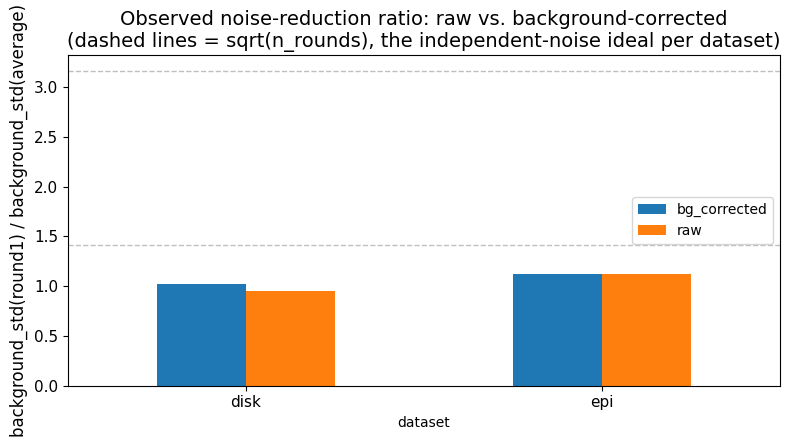

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.noise_ratio_comparison.png


In [9]:
noise_rows = []
for dataset_label, R in RESULTS.items():
    n = R["n_rounds_averaged"]
    bg_mask = R["round1_raw"] < np.median(R["round1_raw"])
    for pipeline, r1_key, avg_key in (("raw", "round1_raw", "average_raw"),
                                       ("bg_corrected", "round1_corrected", "average_corrected")):
        std_before = float(np.std(R[r1_key][bg_mask]))
        std_after  = float(np.std(R[avg_key][bg_mask]))
        noise_rows.append({
            "dataset": dataset_label, "pipeline": pipeline, "n_rounds_averaged": n,
            "background_std_round1": std_before, "background_std_average": std_after,
            "observed_ratio": std_before / std_after, "expected_ratio_if_independent_noise": np.sqrt(n),
        })

noise_df = pd.DataFrame(noise_rows)
print(noise_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = noise_df.pivot(index="dataset", columns="pipeline", values="observed_ratio")
pivot.plot(kind="bar", ax=ax)
for dataset_label, R in RESULTS.items():
    ax.axhline(np.sqrt(R["n_rounds_averaged"]), color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("background_std(round1) / background_std(average)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Observed noise-reduction ratio: raw vs. background-corrected\n"
             "(dashed lines = sqrt(n_rounds), the independent-noise ideal per dataset)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.noise_ratio_comparison.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")